In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets  # Asegúrate de importar datasets aquí
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np

SVC con kernel=linear, Accuracy: 0.8338368580060423
SVC con kernel=poly, Accuracy: 0.8217522658610272
SVC con kernel=rbf, Accuracy: 0.8640483383685801


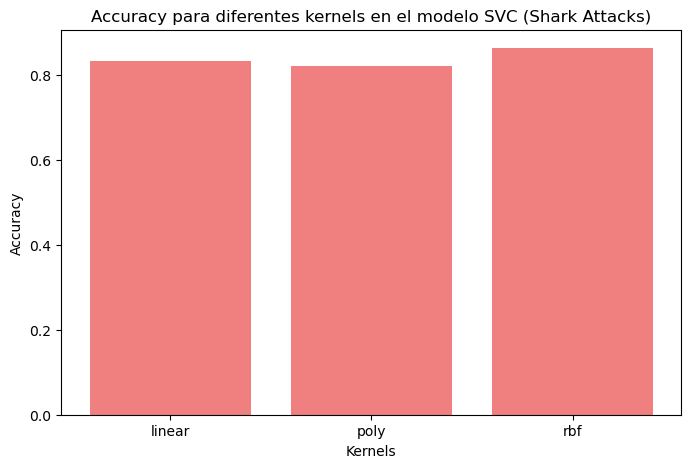

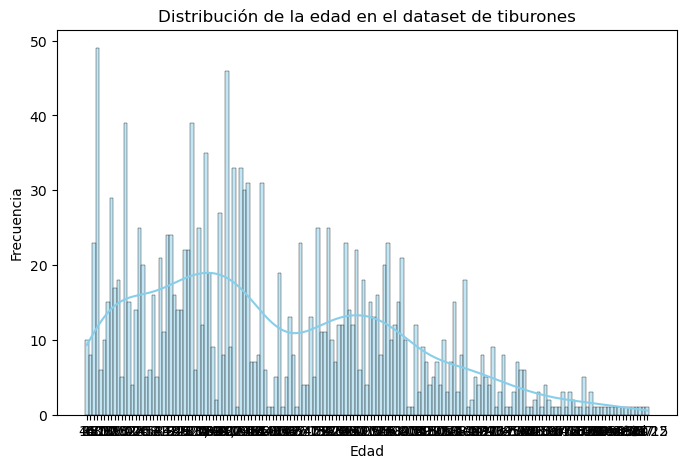

SVC con kernel=linear, Accuracy: 0.6216216216216216
SVC con kernel=poly, Accuracy: 0.6216216216216216
SVC con kernel=rbf, Accuracy: 0.6756756756756757


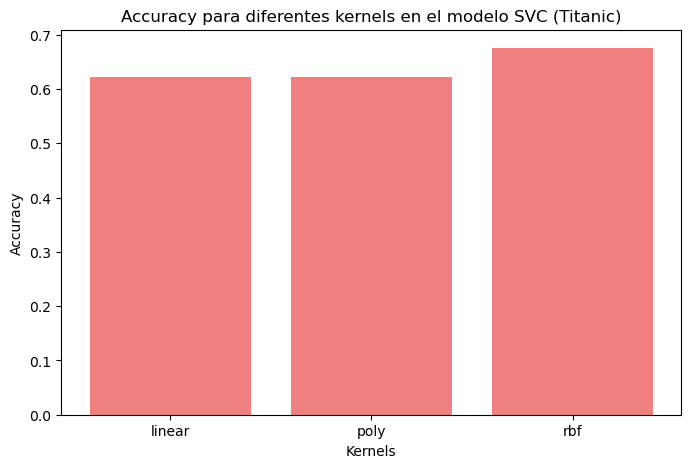

In [2]:
# Cargar el dataset de ataques de tiburones
shark_attacks = pd.read_csv('global_shark_attacks.csv')

# Preprocesar el dataset (por ejemplo, eliminar filas con valores nulos)
shark_attacks.dropna(inplace=True)

# Corregir los nombres de las columnas eliminando espacios extras
shark_attacks.columns = shark_attacks.columns.str.strip()

# Verifica los nombres de las columnas después de limpiar
#print("Columnas después de limpiar espacios:", shark_attacks.columns)

# Seleccionar características y etiquetas con los nombres correctos
X_shark = shark_attacks[['year', 'type', 'country', 'area', 'activity', 'sex', 'age']]  # Asegúrate de usar los nombres correctos
y_shark = shark_attacks['fatal_y_n']  # La columna 'fatal_y_n' es la que corresponde a la variable objetivo

# Convertir características categóricas a numéricas
X_shark = pd.get_dummies(X_shark)

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train_shark, X_test_shark, y_train_shark, y_test_shark = train_test_split(X_shark, y_shark, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_shark = scaler.fit_transform(X_train_shark)
X_test_shark = scaler.transform(X_test_shark)

# Graficar Accuracy para SVC en Shark Attacks
accuracy_values_shark = []
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svc = SVC(kernel=kernel)
    svc.fit(X_train_shark, y_train_shark)
    y_pred_shark = svc.predict(X_test_shark)
    accuracy = accuracy_score(y_test_shark, y_pred_shark)
    accuracy_values_shark.append(accuracy)
    print(f'SVC con kernel={kernel}, Accuracy: {accuracy}')

# Graficar los Accuracy para cada kernel en Shark Attacks
plt.figure(figsize=(8, 5))
plt.bar(kernels, accuracy_values_shark, color='lightcoral')
plt.title('Accuracy para diferentes kernels en el modelo SVC (Shark Attacks)')
plt.xlabel('Kernels')
plt.ylabel('Accuracy')
plt.show()

# Graficar la distribución de las edades en el dataset de tiburones
plt.figure(figsize=(8, 5))
sns.histplot(shark_attacks['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de la edad en el dataset de tiburones')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
# Cargar el dataset de Titanic
titanic = pd.read_csv('train.csv')

# Preprocesar el dataset (por ejemplo, eliminar filas con valores nulos)
titanic.dropna(inplace=True)

# Corregir los nombres de las columnas eliminando espacios extras
titanic.columns = titanic.columns.str.strip()

# Verifica los nombres de las columnas después de limpiar
#print("Columnas después de limpiar espacios:", titanic.columns)

# Seleccionar características y etiquetas con los nombres correctos
X_titanic = titanic[['Pclass', 'Age', 'Fare', 'Sex', 'Embarked']]  # Asegúrate de usar los nombres correctos
y_titanic = titanic['Survived']  # La columna 'Survived' es la que corresponde a la variable objetivo

# Convertir características categóricas a numéricas
X_titanic = pd.get_dummies(X_titanic, columns=['Sex', 'Embarked'], drop_first=True)

# Dividir el dataset en conjunto de entrenamiento y prueba
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train_titanic = scaler.fit_transform(X_train_titanic)
X_test_titanic = scaler.transform(X_test_titanic)

# Graficar Accuracy para SVC en Titanic
accuracy_values_titanic = []
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svc = SVC(kernel=kernel)
    svc.fit(X_train_titanic, y_train_titanic)
    y_pred_titanic = svc.predict(X_test_titanic)
    accuracy = accuracy_score(y_test_titanic, y_pred_titanic)
    accuracy_values_titanic.append(accuracy)
    print(f'SVC con kernel={kernel}, Accuracy: {accuracy}')

# Graficar los Accuracy para cada kernel en Titanic
plt.figure(figsize=(8, 5))
plt.bar(kernels, accuracy_values_titanic, color='lightcoral')
plt.title('Accuracy para diferentes kernels en el modelo SVC (Titanic)')
plt.xlabel('Kernels')
plt.ylabel('Accuracy')
plt.show()

VotingClassifier Accuracy (Titanic): 0.6756756756756757
VotingClassifier Accuracy (Shark Attacks): 0.8368580060422961


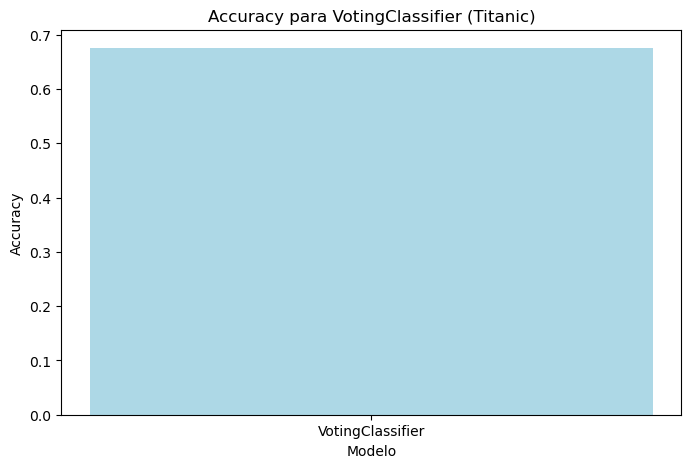

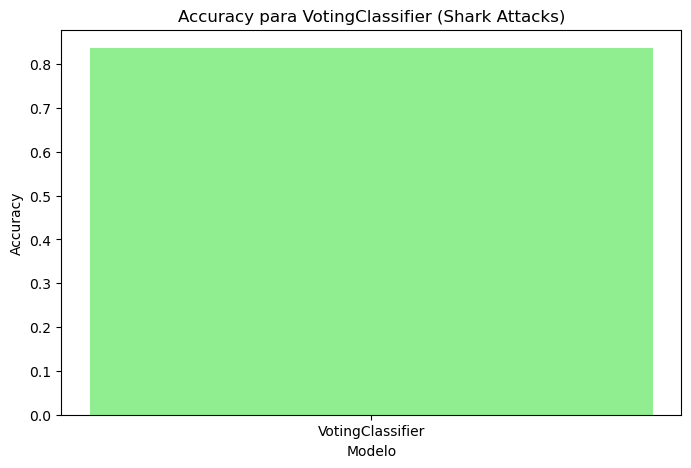

In [3]:
# VotingClassifier para Titanic
clf1_titanic = LogisticRegression()
clf2_titanic = DecisionTreeClassifier()
clf3_titanic = KNeighborsClassifier()

voting_clf_titanic = VotingClassifier(estimators=[('lr', clf1_titanic), ('dt', clf2_titanic), ('knn', clf3_titanic)], voting='hard')
voting_clf_titanic.fit(X_train_titanic, y_train_titanic)
y_pred_voting_titanic = voting_clf_titanic.predict(X_test_titanic)
accuracy_voting_titanic = accuracy_score(y_test_titanic, y_pred_voting_titanic)
print(f'VotingClassifier Accuracy (Titanic): {accuracy_voting_titanic}')

# VotingClassifier para Shark Attacks
clf1_shark = LogisticRegression()
clf2_shark = DecisionTreeClassifier()
clf3_shark = KNeighborsClassifier()

voting_clf_shark = VotingClassifier(estimators=[('lr', clf1_shark), ('dt', clf2_shark), ('knn', clf3_shark)], voting='hard')
voting_clf_shark.fit(X_train_shark, y_train_shark)
y_pred_voting_shark = voting_clf_shark.predict(X_test_shark)
accuracy_voting_shark = accuracy_score(y_test_shark, y_pred_voting_shark)
print(f'VotingClassifier Accuracy (Shark Attacks): {accuracy_voting_shark}')

# Graficar Accuracy para VotingClassifier en Titanic
plt.figure(figsize=(8, 5))
plt.bar(['VotingClassifier'], [accuracy_voting_titanic], color='lightblue')
plt.title('Accuracy para VotingClassifier (Titanic)')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.show()

# Graficar Accuracy para VotingClassifier en Shark Attacks
plt.figure(figsize=(8, 5))
plt.bar(['VotingClassifier'], [accuracy_voting_shark], color='lightgreen')
plt.title('Accuracy para VotingClassifier (Shark Attacks)')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.show()


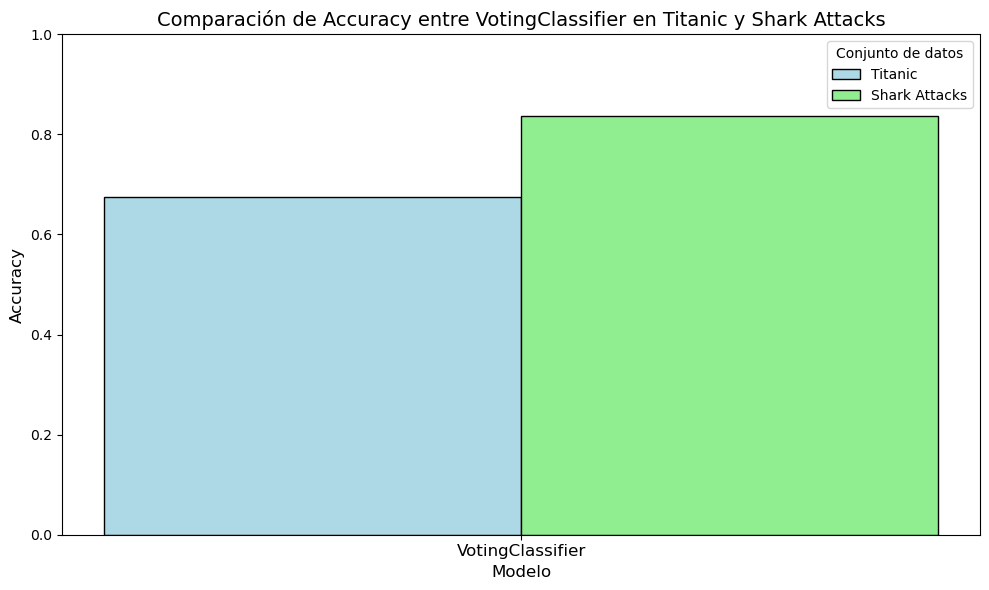

In [7]:
# Valores de precisión de los modelos
model_names = ['VotingClassifier']
accuracy_values = [accuracy_voting_titanic, accuracy_voting_shark]

# Colores para los gráficos
colors = ['lightblue', 'lightgreen']

# Crear una figura más clara
plt.figure(figsize=(10, 6))

# Crear un gráfico de barras para comparar las precisiones de Titanic y Shark Attacks
bar_width = 0.35
index = np.arange(len(model_names))

# Crear las barras para Titanic y Shark Attacks
plt.bar(index, accuracy_values[0], bar_width, color='lightblue', label='Titanic', edgecolor='black')
plt.bar(index + bar_width, accuracy_values[1], bar_width, color='lightgreen', label='Shark Attacks', edgecolor='black')

# Añadir etiquetas, título y mejorar la visualización
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparación de Accuracy entre VotingClassifier en Titanic y Shark Attacks', fontsize=14)
plt.xticks(index + bar_width / 2, model_names, fontsize=12)
plt.ylim(0, 1)  # Aseguramos que el eje y esté entre 0 y 1 para que la comparación sea clara

# Agregar leyenda
plt.legend(title="Conjunto de datos", fontsize=10)

# Mostrar la gráfica
plt.tight_layout()
plt.show()